## Data Exploration

In [97]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [98]:
df = pd.read_csv("data.csv")
print("Shape:", df.shape)
print("\nCondition value counts:")
print(df["Condition"].value_counts(dropna=False))
print("\nFirst rows (key columns):")
display(df[["Condition", "ageatcollection", "LACTIC", "CITRIC", "ZLACTIC", "ZCITRIC"]].head(10))

Shape: (82, 70)

Condition value counts:
Condition
PCCB             31
PCCA             17
mut0             11
PA HET           10
Healthy Vol.      6
PCCA w/ LT        3
mut0 w/ LKT       1
PCCB w/ LT        1
mut0 w/ 2x KT     1
PCCB w/ KT        1
Name: count, dtype: int64

First rows (key columns):


,Condition,ageatcollection,LACTIC,CITRIC,ZLACTIC,ZCITRIC
0,Healthy Vol.,29.408333,1380.900000,129.000000,-0.875295,-0.502821
1,Healthy Vol.,22.769444,876.600000,89.500000,-1.247122,-1.219508
2,Healthy Vol.,21.613889,1347.300000,94.400000,-0.900069,-1.130603
3,Healthy Vol.,33.644444,1229.800000,133.000000,-0.986703,-0.430245
4,PA HET,46.655556,3394.574232,203.053702,0.609412,0.840808
5,mut0,16.461111,2097.800000,91.000000,-0.346716,-1.192292
6,Healthy Vol.,25.041667,1727.700000,140.500000,-0.619595,-0.294165
7,mut0,23.902778,1401.300000,99.000000,-0.860254,-1.047141
8,mut0,8.297222,1225.200000,165.400000,-0.990095,0.157620
9,PA HET,33.702778,2641.678349,270.173930,0.054293,2.058636


In [99]:
print("Data types:")
print(df.dtypes.value_counts())
print("\nMissing values per column (top 25):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(25))

Data types:
float64    41
object     24
int64       5
Name: count, dtype: int64

Missing values per column (top 25):
Series([], dtype: int64)


In [100]:
z_cols = [c for c in df.columns if c.startswith("Z") and len(c) > 1]
feature_cols = ["ageatcollection"] + z_cols
feature_cols = [c for c in feature_cols if c in df.columns]
print("Feature columns:", len(feature_cols))
print(feature_cols[:5], "...", feature_cols[-3:])

Feature columns: 21
['ageatcollection', 'ZLACTIC', 'Z@2OHBUT', 'Z@3OHBUT', 'ZPYRUVIC'] ... ['Z@2KETOISOCAPROIC', 'Z@2MECITRIC', 'Z@2KETOGLUTARIC']


In [101]:
numeric_df = df[feature_cols].apply(pd.to_numeric, errors="coerce")
print("Summary statistics (features):")
display(numeric_df.describe())

Summary statistics (features):


,ageatcollection,ZLACTIC,Z@2OHBUT,Z@3OHBUT,ZPYRUVIC,ZCISACONITIC,ZCITRIC,Z@3OHPROPIONIC,Z@3OH2MEBUT,Z@3OHIVAl,...,ZFUMARIC,Z@3MEGLUTACONIC,ZMALIC,Z@2KETOISOVALERIC,Z@2KETOBUTl,ZACETOACETICl,Z@3ME2KETOVALERIC,Z@2KETOISOCAPROIC,Z@2MECITRIC,Z@2KETOGLUTARIC
count,82.000000,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,...,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01,8.200000e+01
mean,22.869275,3.658537e-11,2.439023e-11,1.219514e-11,1.760110e-17,-2.439025e-11,-1.219513e-11,1.219515e-11,-1.219511e-11,1.585366e-10,...,-9.477514e-18,4.878048e-11,-7.317074e-11,-1.219512e-11,-2.439024e-11,4.878046e-11,1.219508e-11,-4.878048e-11,-1.878579e-17,2.439025e-11
std,13.784334,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,2.369444,-1.273444e+00,-1.472739e+00,-4.052404e-01,-1.294604e+00,-9.157600e-01,-1.598718e+00,-9.020608e-01,-1.417783e+00,-9.614147e-01,...,-1.330000e+00,-1.168474e+00,-1.332893e+00,-1.638077e+00,-1.419834e+00,-3.869880e-01,-6.775426e-01,-1.409865e+00,-7.452097e-01,-1.732546e+00
25%,11.764583,-6.554101e-01,-7.469876e-01,-3.276456e-01,-5.752245e-01,-5.724045e-01,-8.543608e-01,-7.382754e-01,-6.268076e-01,-9.614147e-01,...,-1.003434e+00,-5.942656e-01,-9.165486e-01,-6.449397e-01,-9.412251e-01,-3.180479e-01,-4.040875e-01,-7.372353e-01,-5.644762e-01,-9.453242e-01
50%,20.948611,-2.215050e-01,-1.729174e-01,-2.111996e-01,-1.062153e-01,-3.275712e-01,-1.656253e-02,-4.919554e-01,-3.062073e-01,-9.610400e-02,...,2.264836e-01,-2.593110e-01,-1.336465e-01,-2.343583e-01,2.342652e-01,-2.684490e-01,-2.956236e-01,-2.320006e-01,-2.780687e-01,2.932915e-01
75%,33.688194,3.175922e-01,5.769488e-01,-8.335121e-02,3.038021e-01,1.865135e-01,6.487250e-01,4.120432e-01,3.677137e-01,8.929209e-01,...,9.356530e-01,1.242796e-01,7.078539e-01,5.819348e-01,6.923943e-01,-1.316084e-01,4.556860e-02,3.747266e-01,1.468018e-01,9.049597e-01
max,53.361111,4.216807e+00,3.852570e+00,7.464893e+00,4.315694e+00,4.467502e+00,2.829455e+00,2.992439e+00,4.403206e+00,2.736362e+00,...,1.932500e+00,4.624570e+00,2.503267e+00,3.826928e+00,3.301286e+00,7.560581e+00,7.422355e+00,3.667329e+00,6.365666e+00,1.894297e+00


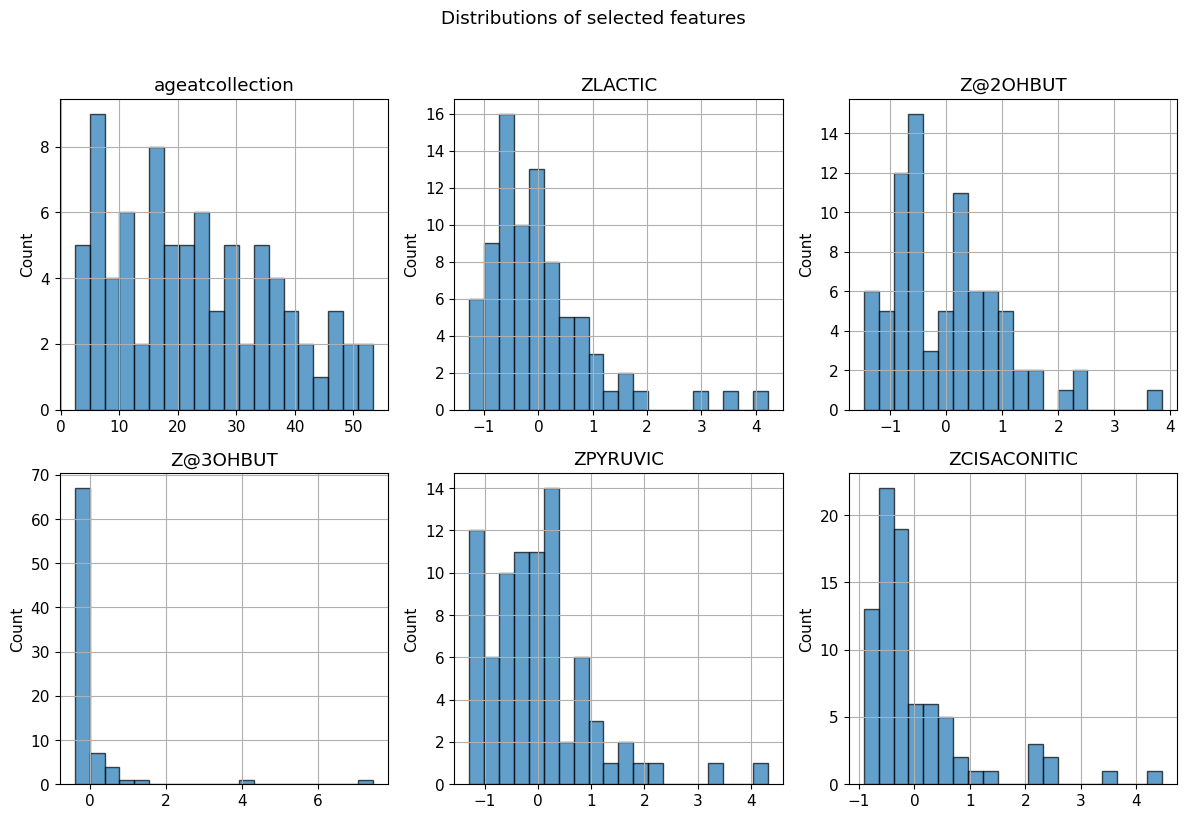

In [102]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(feature_cols[:6]):
    numeric_df[col].dropna().hist(ax=axes[i], bins=20, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
plt.suptitle("Distributions of selected features", y=1.02)
plt.tight_layout()
plt.show()

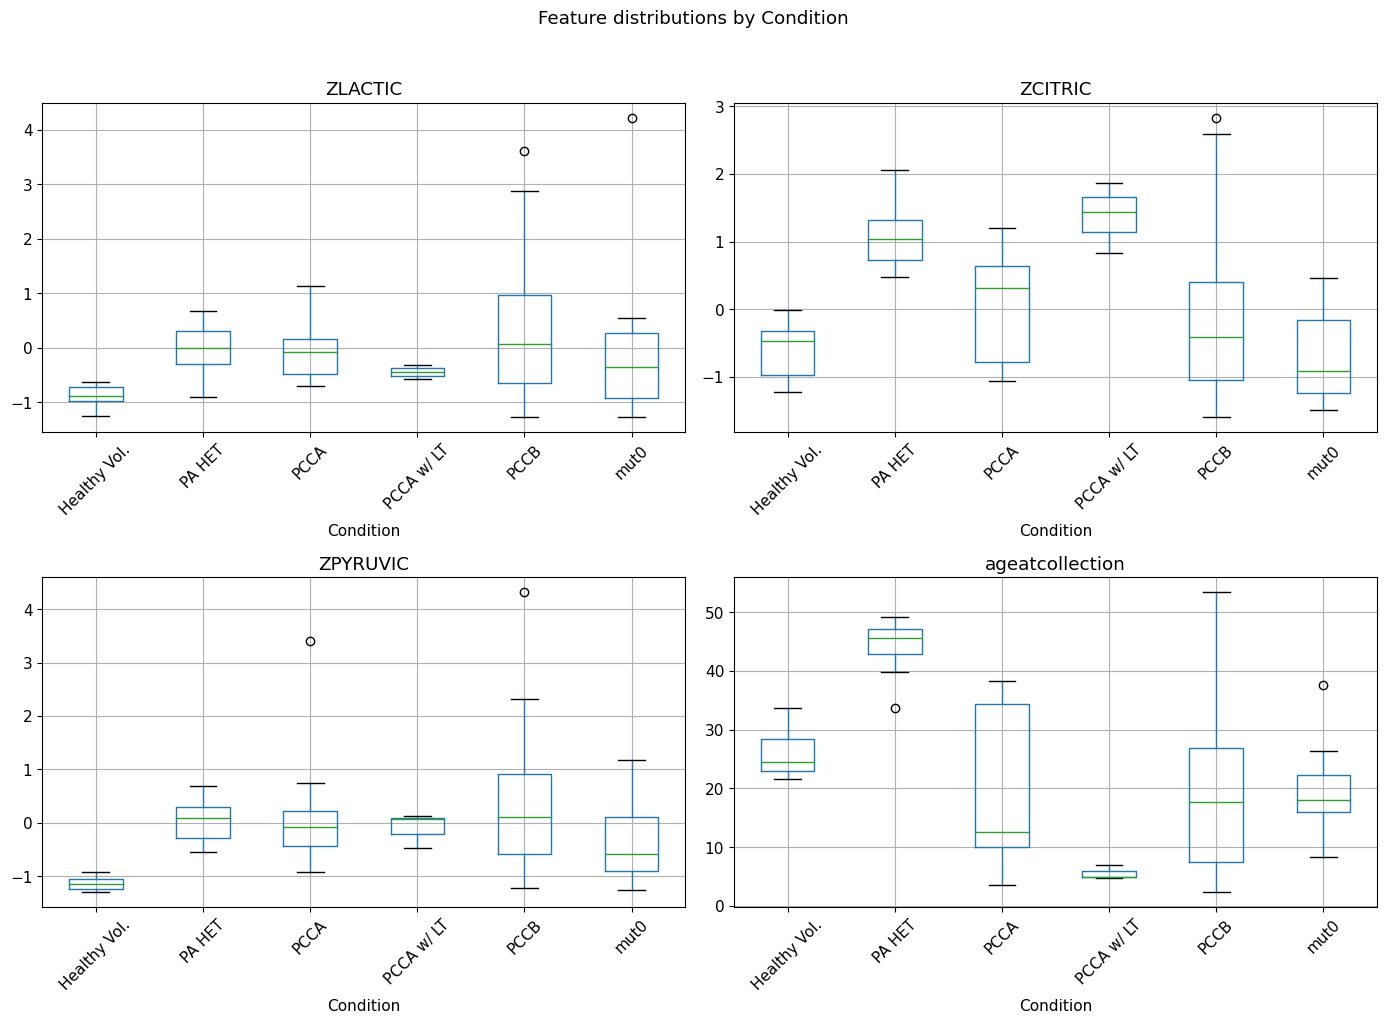

In [103]:
plot_df = df.copy()
plot_df["Condition_plot"] = plot_df["Condition"].fillna("(missing)")
cond_counts = plot_df["Condition_plot"].value_counts()
top_conds = cond_counts[cond_counts >= 2].index.tolist()
plot_df = plot_df[plot_df["Condition_plot"].isin(top_conds)]
for col in ["ZLACTIC", "ZCITRIC", "ZPYRUVIC", "ageatcollection"]:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ["ZLACTIC", "ZCITRIC", "ZPYRUVIC", "ageatcollection"]):
    plot_df.boxplot(column=col, by="Condition_plot", ax=ax, rot=45)
    ax.set_title(col)
    ax.set_xlabel("Condition")
plt.suptitle("Feature distributions by Condition", y=1.02)
plt.tight_layout()
plt.show()

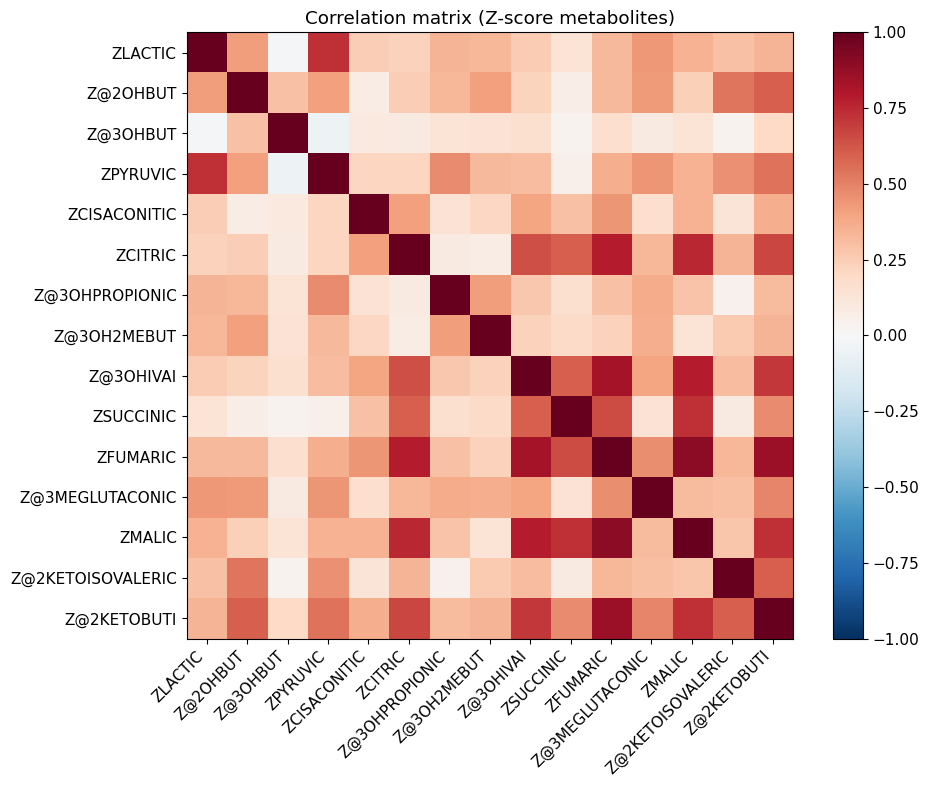

In [104]:
corr_cols = [c for c in feature_cols if c.startswith("Z")][:15]
corr_df = numeric_df[corr_cols].dropna(how="all")
if len(corr_df) > 0:
    corr = corr_df.corr()
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation matrix (Z-score metabolites)")
    plt.tight_layout()
    plt.show()

In [ ]:
# Correlation matrix including only PCCA/PCCB cases
df_pcc = df[df["Condition"].isin(["PCCA", "PCCB"])].copy()
numeric_df_pcc = df_pcc[feature_cols].apply(pd.to_numeric, errors="coerce")
corr_cols_pcc = [c for c in feature_cols if c.startswith("Z")][:15]
corr_df_pcc = numeric_df_pcc[corr_cols_pcc].dropna(how="all")
if len(corr_df_pcc) > 0:
    corr_pcc = corr_df_pcc.corr()
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_pcc, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr_pcc.columns)), corr_pcc.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_pcc.columns)), corr_pcc.columns)
    plt.title("Correlation matrix (Z-score metabolites) — PCCA/PCCB cases only (n={})".format(len(corr_df_pcc)))
    plt.tight_layout()
    plt.show()
else:
    print("No data after filtering to PCCA/PCCB.")

## One-hot encode Condition

Map condition to 4 classes: Healthy Vol., mut0, PA HET, and **PCCA/PCCB** (PCCA and PCCB grouped). Transplant variants (PCCA w/ LT, PCCB w/ LT, PCCB w/ KT) map to PCCA/PCCB; mut0 w/ 2x KT and mut0 w/ LKT map to mut0.

In [105]:
CONDITION_CLASSES = [
    "Healthy Vol.", "mut0", "PA HET", "PCCA/PCCB"
]
# Map to 4 classes: group PCCA and PCCB (and transplant variants) as "PCCA/PCCB"
condition_map = {
    "PCCA": "PCCA/PCCB",
    "PCCB": "PCCA/PCCB",
    "PCCA w/ LT": "PCCA/PCCB",
    "PCCB w/ LT": "PCCA/PCCB",
    "PCCB w/ KT": "PCCA/PCCB",
    "mut0 w/ 2x KT": "mut0",
    "mut0 w/ LKT": "mut0",
}
df_ml = df.copy()
df_ml["Condition_mapped"] = df_ml["Condition"].replace(condition_map)
# Restrict to the 4 target classes
df_ml = df_ml[df_ml["Condition_mapped"].isin(CONDITION_CLASSES)].copy()
print("Samples per class after mapping:")
print(df_ml["Condition_mapped"].value_counts().sort_index())
# One-hot encode
condition_dummies = pd.get_dummies(df_ml["Condition_mapped"], prefix="cond")
df_ml = pd.concat([df_ml, condition_dummies], axis=1)
dummy_cols = [c for c in df_ml.columns if c.startswith("cond_")]
print("\nOne-hot columns:", dummy_cols)

Samples per class after mapping:
Condition_mapped
Healthy Vol.     6
PA HET          10
PCCA/PCCB       53
mut0            13
Name: count, dtype: int64

One-hot columns: ['cond_Healthy Vol.', 'cond_PA HET', 'cond_PCCA/PCCB', 'cond_mut0']


In [106]:
# Use MetaboliteConditionClassifier (z-score features by default)
from metabolites_classifier import MetaboliteConditionClassifier

clf_z = MetaboliteConditionClassifier(df_ml, feature_set="zscore")
clf_z.prepare_data()
print("Feature set: zscore | Features:", len(clf_z.get_feature_columns()))
print("Sample count:", len(clf_z.y_))
print("Class distribution:")
print(clf_z.y_.value_counts().sort_index())
# Expose for K-means / plotting later
X_train_s = clf_z.X_train_s_
X_test_s = clf_z.X_test_s_
y_train = clf_z.y_train_
y_test = clf_z.y_test_

Feature set: zscore | Features: 21
Sample count: 82
Class distribution:
Condition_mapped
Healthy Vol.     6
PA HET          10
PCCA/PCCB       53
mut0            13
Name: count, dtype: int64


## Classification: multiple ML models

Train/test split, scale features, then train several classifiers and report accuracy and per-class metrics.

In [107]:
# Run all models (including XGBoost with label encoding)
results_z = clf_z.run_models(include_xgb=True)
display(pd.DataFrame(results_z))


--- Logistic Regression ---
CV accuracy: 0.868 (+/- 0.068)
Test accuracy: 0.857
              precision    recall  f1-score   support

Healthy Vol.       1.00      1.00      1.00         1
      PA HET       1.00      0.67      0.80         3
   PCCA/PCCB       0.87      0.93      0.90        14
        mut0       0.67      0.67      0.67         3

    accuracy                           0.86        21
   macro avg       0.88      0.82      0.84        21
weighted avg       0.86      0.86      0.85        21


--- Random Forest ---
CV accuracy: 0.918 (+/- 0.075)
Test accuracy: 0.762
              precision    recall  f1-score   support

Healthy Vol.       0.50      1.00      0.67         1
      PA HET       1.00      1.00      1.00         3
   PCCA/PCCB       0.80      0.86      0.83        14
        mut0       0.00      0.00      0.00         3

    accuracy                           0.76        21
   macro avg       0.57      0.71      0.62        21
weighted avg       0.70      

,Model,CV Accuracy (mean),CV std,Test Accuracy
0,Logistic Regression,0.867949,0.067670,0.857143
1,Random Forest,0.917949,0.074580,0.761905
2,SVM (RBF),0.720513,0.044522,0.761905
3,K-Nearest Neighbors,0.770513,0.032281,0.761905
4,Decision Tree,0.785897,0.068754,0.714286
5,XGBoost,0.917949,0.074580,0.761905


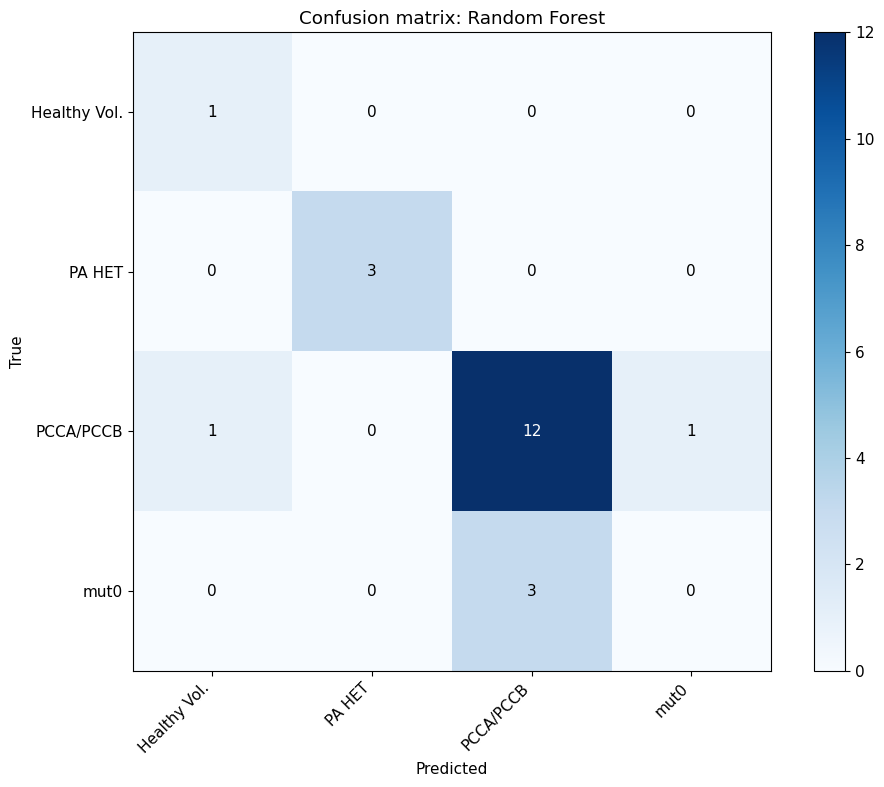

In [108]:
# Confusion matrix for best model (e.g. Random Forest)
clf_z.confusion_matrix_plot("Random Forest")
plt.tight_layout()
plt.show()

### Run with raw (non–Z-score) metabolite features

Compare accuracy when using raw metabolite columns instead of Z-scores.

In [109]:
# Run with non–Z-score (raw metabolite) features
clf_raw = MetaboliteConditionClassifier(df_ml, feature_set="raw")
clf_raw.prepare_data()
print("Feature set: raw | Features:", len(clf_raw.get_feature_columns()))
results_raw = clf_raw.run_models(include_xgb=True)
display(pd.DataFrame(results_raw))

Feature set: raw | Features: 21

--- Logistic Regression ---
CV accuracy: 0.868 (+/- 0.068)
Test accuracy: 0.857
              precision    recall  f1-score   support

Healthy Vol.       1.00      1.00      1.00         1
      PA HET       1.00      0.67      0.80         3
   PCCA/PCCB       0.87      0.93      0.90        14
        mut0       0.67      0.67      0.67         3

    accuracy                           0.86        21
   macro avg       0.88      0.82      0.84        21
weighted avg       0.86      0.86      0.85        21


--- Random Forest ---
CV accuracy: 0.918 (+/- 0.075)
Test accuracy: 0.762
              precision    recall  f1-score   support

Healthy Vol.       0.50      1.00      0.67         1
      PA HET       1.00      1.00      1.00         3
   PCCA/PCCB       0.80      0.86      0.83        14
        mut0       0.00      0.00      0.00         3

    accuracy                           0.76        21
   macro avg       0.57      0.71      0.62        

,Model,CV Accuracy (mean),CV std,Test Accuracy
0,Logistic Regression,0.867949,0.067670,0.857143
1,Random Forest,0.917949,0.074580,0.761905
2,SVM (RBF),0.720513,0.044522,0.761905
3,K-Nearest Neighbors,0.770513,0.032281,0.761905
4,Decision Tree,0.785897,0.068754,0.714286
5,XGBoost,0.917949,0.074580,0.761905


### Feature selection then rerun

Select top k most significant features (e.g. ANOVA F-value or RF importance), then run models to see if accuracy improves.

In [110]:
from metabolites_classifier import MetaboliteConditionClassifier

clf_sel = MetaboliteConditionClassifier(df_ml, feature_set="zscore")
clf_sel.prepare_data()

# clf_sel.select_features(method="kbest", k=10)

clf_sel.select_features(method="rf", k=10)
print("Selected features:", clf_sel.get_feature_columns())
results_sel = clf_sel.run_models(include_xgb=True)
display(pd.DataFrame(results_sel))

Selected features: ['Z@2KETOISOCAPROIC', 'Z@3MEGLUTACONIC', 'Z@2KETOBUTl', 'ZACETOACETICl', 'ZCITRIC', 'ZSUCCINIC', 'ageatcollection', 'Z@2KETOISOVALERIC', 'Z@2MECITRIC', 'Z@3OHPROPIONIC']

--- Logistic Regression ---
CV accuracy: 0.851 (+/- 0.098)
Test accuracy: 0.905
              precision    recall  f1-score   support

Healthy Vol.       1.00      1.00      1.00         1
      PA HET       1.00      1.00      1.00         3
   PCCA/PCCB       0.93      0.93      0.93        14
        mut0       0.67      0.67      0.67         3

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21


--- Random Forest ---
CV accuracy: 0.935 (+/- 0.062)
Test accuracy: 0.762
              precision    recall  f1-score   support

Healthy Vol.       0.50      1.00      0.67         1
      PA HET       1.00      1.00      1.00         3
   PCCA/PCCB       0.85      0.79      0.81        14
   

,Model,CV Accuracy (mean),CV std,Test Accuracy
0,Logistic Regression,0.851282,0.098092,0.904762
1,Random Forest,0.934615,0.062070,0.761905
2,SVM (RBF),0.737179,0.063846,0.761905
3,K-Nearest Neighbors,0.870513,0.109268,0.761905
4,Decision Tree,0.835897,0.052954,0.714286
5,XGBoost,0.901282,0.062755,0.714286


## Publication-style figures

Figures for the best pipeline (feature selection + Logistic Regression): model comparison across pipelines, confusion matrix, feature importance (coefficients), per-class metrics, and ROC curves.

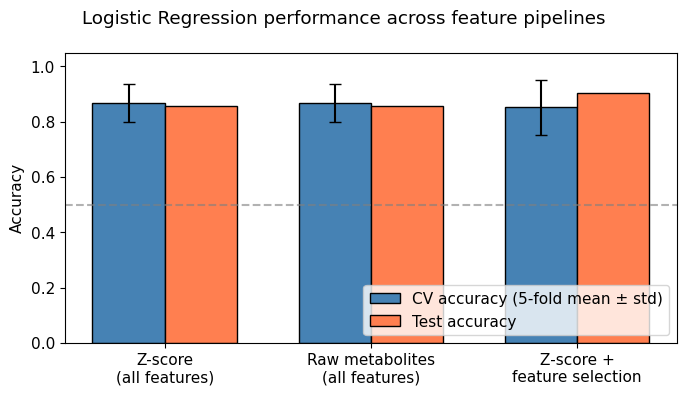

In [111]:
# 1) Model comparison: Logistic Regression across pipelines (Z-score, Raw, Feature selection)
from matplotlib import rcParams
rcParams["font.size"] = 11

lr_rows = [
    (results_z, "Z-score\n(all features)"),
    (results_raw, "Raw metabolites\n(all features)"),
    (results_sel, "Z-score +\nfeature selection"),
]
labels = [x[1] for x in lr_rows]
cv_means = []
cv_stds = []
test_accs = []
for res, _ in lr_rows:
    lr = next(r for r in res if r["Model"] == "Logistic Regression")
    cv_means.append(lr["CV Accuracy (mean)"])
    cv_stds.append(lr["CV std"])
    test_accs.append(lr["Test Accuracy"])

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width / 2, cv_means, width, yerr=cv_stds, label="CV accuracy (5-fold mean ± std)", capsize=4, color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width / 2, test_accs, width, label="Test accuracy", color="coral", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.6)
fig.suptitle("Logistic Regression performance across feature pipelines")
plt.tight_layout()
plt.show()

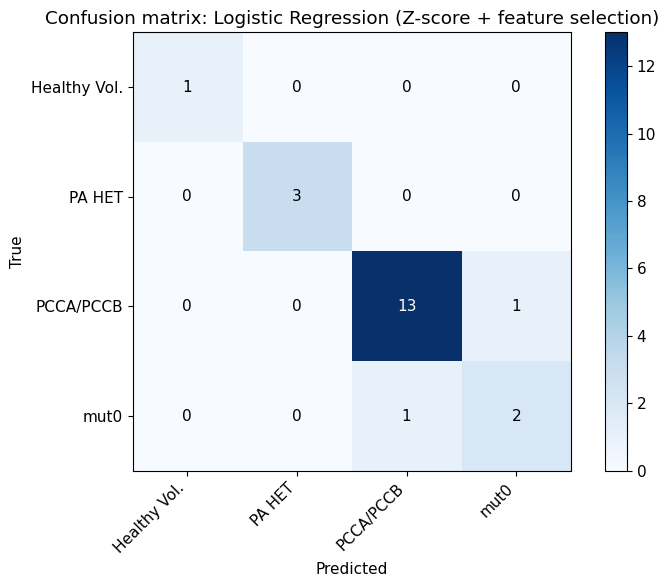

In [112]:
# 2) Confusion matrix for best model (Feature selection + Logistic Regression)
fig, ax = plt.subplots(figsize=(8, 6))
clf_sel.confusion_matrix_plot("Logistic Regression", ax=ax)
ax.set_title("Confusion matrix: Logistic Regression (Z-score + feature selection)")
plt.tight_layout()
plt.show()

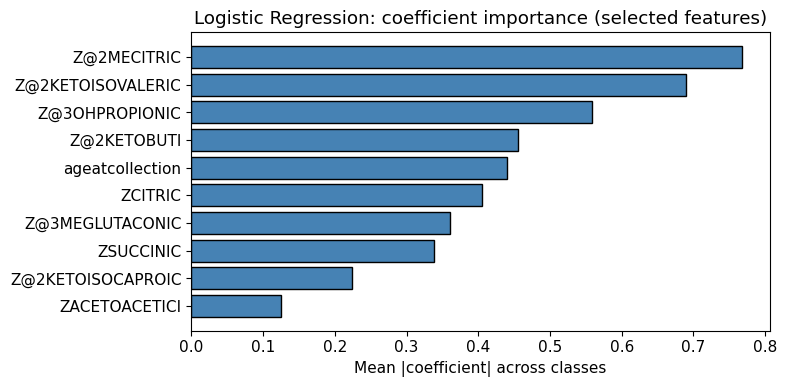

In [113]:
# 3) Feature importance (Logistic Regression: coefficient importance on selected features)
from sklearn.linear_model import LogisticRegression as LR

lr_fit = LR(max_iter=2000, random_state=42)
lr_fit.fit(clf_sel.X_train_s_, clf_sel.y_train_)
# Mean absolute coefficient per feature across classes
coef = np.abs(lr_fit.coef_).mean(axis=0)
names = clf_sel.get_feature_columns()
order = np.argsort(coef)[::-1]
coef = coef[order]
names = [names[i] for i in order]

fig, ax = plt.subplots(figsize=(8, max(4, len(names) * 0.35)))
ax.barh(range(len(names)), coef, color="steelblue", edgecolor="black")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("Mean |coefficient| across classes")
ax.set_title("Logistic Regression: coefficient importance (selected features)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

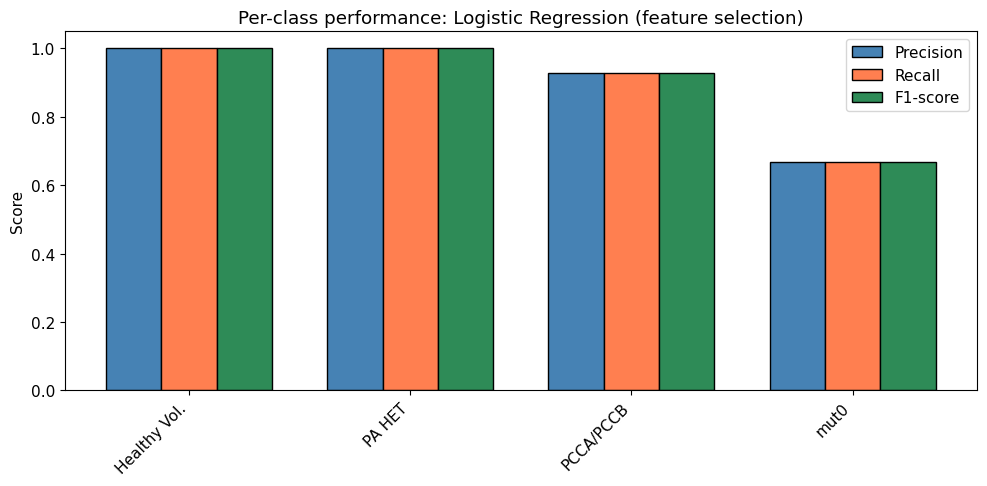

              precision    recall  f1-score   support

Healthy Vol.       1.00      1.00      1.00         1
      PA HET       1.00      1.00      1.00         3
   PCCA/PCCB       0.93      0.93      0.93        14
        mut0       0.67      0.67      0.67         3

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



In [114]:
# 4) Per-class precision, recall, F1 for best model (Logistic Regression + feature selection)
from sklearn.metrics import precision_recall_fscore_support, classification_report
y_pred_lr = lr_fit.predict(clf_sel.X_test_s_)
precision, recall, f1, _ = precision_recall_fscore_support(clf_sel.y_test_, y_pred_lr, average=None, zero_division=0)
classes = sorted(clf_sel.y_test_.unique())

x = np.arange(len(classes))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precision, width, label="Precision", color="steelblue", edgecolor="black")
ax.bar(x, recall, width, label="Recall", color="coral", edgecolor="black")
ax.bar(x + width, f1, width, label="F1-score", color="seagreen", edgecolor="black")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_title("Per-class performance: Logistic Regression (feature selection)")
plt.tight_layout()
plt.show()
print(classification_report(clf_sel.y_test_, y_pred_lr, zero_division=0))

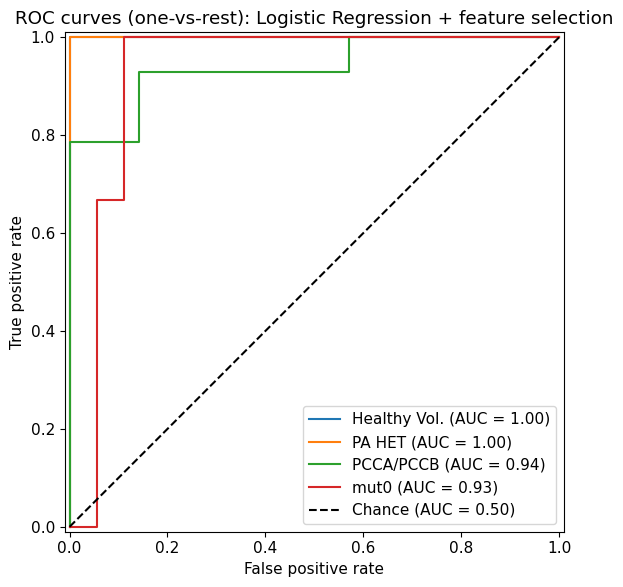

In [115]:
# 5) ROC curves (one-vs-rest) for best model (Logistic Regression + feature selection)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

classes_roc = np.unique(clf_sel.y_train_)
y_test_bin = label_binarize(clf_sel.y_test_, classes=classes_roc)
n_classes = len(classes_roc)
y_score = lr_fit.predict_proba(clf_sel.X_test_s_)

fig, ax = plt.subplots(figsize=(7, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name=classes_roc[i]).plot(ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (one-vs-rest): Logistic Regression + feature selection")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

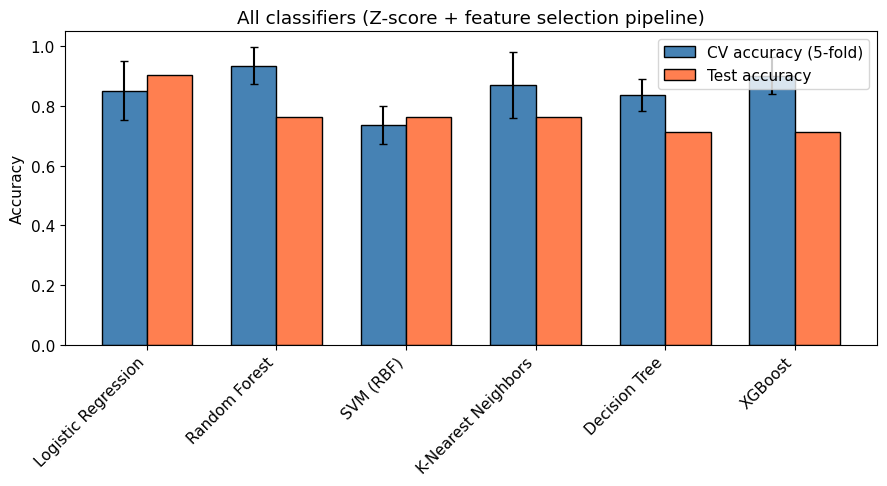

In [116]:
# 6) All models comparison (feature-selection pipeline): CV and test accuracy
res_df = pd.DataFrame(results_sel)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(res_df))
width = 0.35
ax.bar(x - width / 2, res_df["CV Accuracy (mean)"], width, yerr=res_df["CV std"], label="CV accuracy (5-fold)", capsize=3, color="steelblue", edgecolor="black")
ax.bar(x + width / 2, res_df["Test Accuracy"], width, label="Test accuracy", color="coral", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(res_df["Model"], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_title("All classifiers (Z-score + feature selection pipeline)")
plt.tight_layout()
plt.show()

## Publication-style figures: Logistic Regression (Z-score, no feature selection)

Same figure set for the non–feature-selected pipeline with Logistic Regression: model comparison across pipelines, confusion matrix, coefficient importance, per-class metrics, and ROC curves.

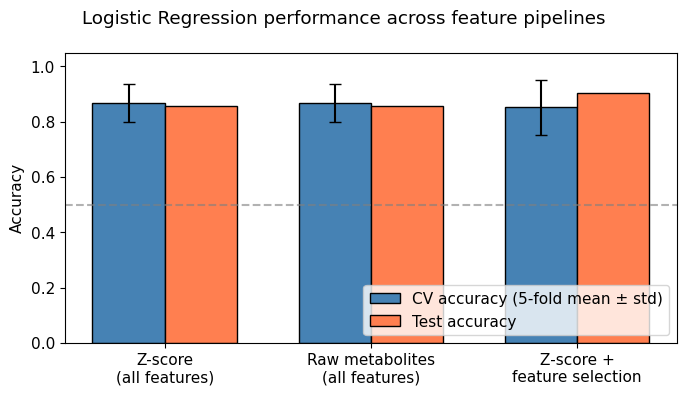

In [117]:
# 1) Model comparison: Logistic Regression across pipelines (Z-score, Raw, Feature selection)
lr_rows = [
    (results_z, "Z-score\n(all features)"),
    (results_raw, "Raw metabolites\n(all features)"),
    (results_sel, "Z-score +\nfeature selection"),
]
labels_lr = [x[1] for x in lr_rows]
cv_means_lr, cv_stds_lr, test_accs_lr = [], [], []
for res, _ in lr_rows:
    lr = next(r for r in res if r["Model"] == "Logistic Regression")
    cv_means_lr.append(lr["CV Accuracy (mean)"])
    cv_stds_lr.append(lr["CV std"])
    test_accs_lr.append(lr["Test Accuracy"])

x = np.arange(len(labels_lr))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, cv_means_lr, width, yerr=cv_stds_lr, label="CV accuracy (5-fold mean ± std)", capsize=4, color="steelblue", edgecolor="black")
ax.bar(x + width / 2, test_accs_lr, width, label="Test accuracy", color="coral", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(labels_lr)
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.6)
fig.suptitle("Logistic Regression performance across feature pipelines")
plt.tight_layout()
plt.show()

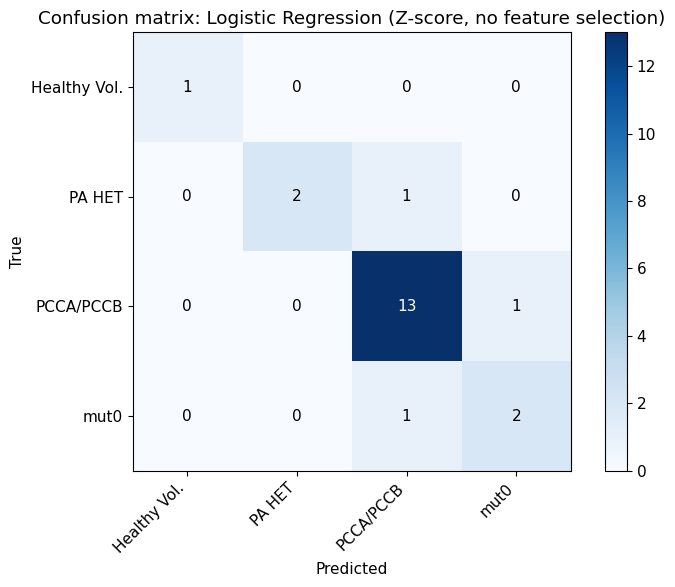

In [118]:
# 2) Confusion matrix: Logistic Regression (Z-score, all features)
fig, ax = plt.subplots(figsize=(8, 6))
clf_z.confusion_matrix_plot("Logistic Regression", ax=ax)
ax.set_title("Confusion matrix: Logistic Regression (Z-score, no feature selection)")
plt.tight_layout()
plt.show()

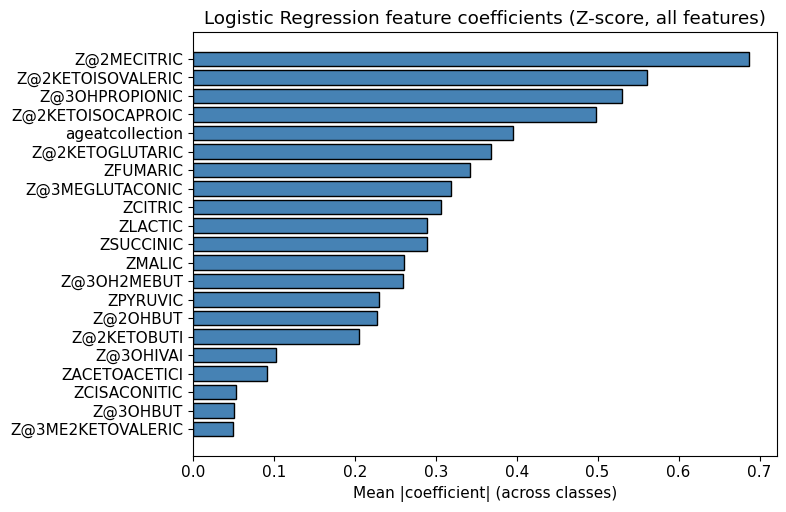

In [119]:
# 3) Feature coefficient importance (Logistic Regression: mean |coefficient| across classes)
from sklearn.linear_model import LogisticRegression
lr_fit = LogisticRegression(max_iter=2000, random_state=42)
lr_fit.fit(clf_z.X_train_s_, clf_z.y_train_)
# Mean absolute coefficient per feature (across one-vs-rest coefficients)
coef_imp = np.abs(lr_fit.coef_).mean(axis=0)
names_lr = clf_z.get_feature_columns()
order_lr = np.argsort(coef_imp)[::-1]
coef_imp = coef_imp[order_lr]
names_lr = [names_lr[i] for i in order_lr]

fig, ax = plt.subplots(figsize=(8, max(4, len(names_lr) * 0.25)))
ax.barh(range(len(names_lr)), coef_imp, color="steelblue", edgecolor="black")
ax.set_yticks(range(len(names_lr)))
ax.set_yticklabels(names_lr)
ax.set_xlabel("Mean |coefficient| (across classes)")
ax.set_title("Logistic Regression feature coefficients (Z-score, all features)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

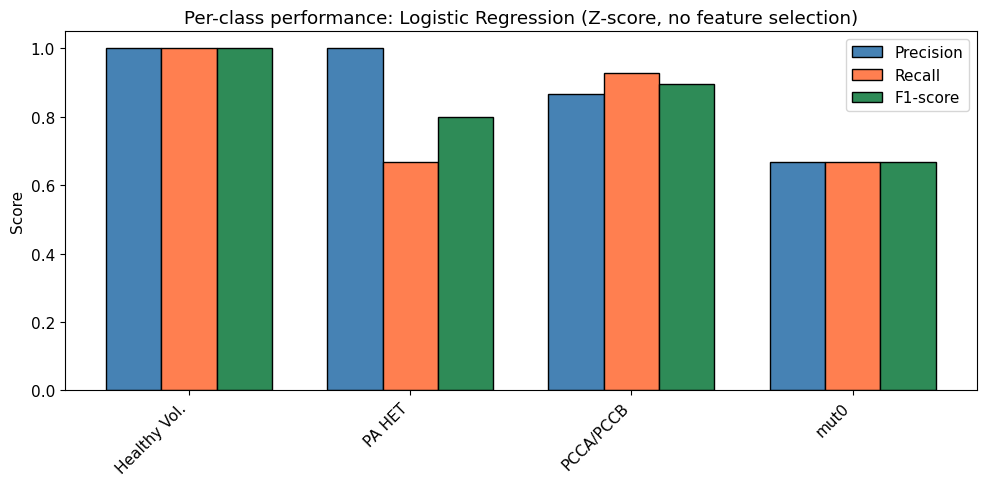

              precision    recall  f1-score   support

Healthy Vol.       1.00      1.00      1.00         1
      PA HET       1.00      0.67      0.80         3
   PCCA/PCCB       0.87      0.93      0.90        14
        mut0       0.67      0.67      0.67         3

    accuracy                           0.86        21
   macro avg       0.88      0.82      0.84        21
weighted avg       0.86      0.86      0.85        21



In [120]:
# 4) Per-class precision, recall, F1: Logistic Regression (Z-score, no feature selection)
from sklearn.metrics import precision_recall_fscore_support, classification_report
y_pred_lr = lr_fit.predict(clf_z.X_test_s_)
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(clf_z.y_test_, y_pred_lr, average=None, zero_division=0)
classes_lr = sorted(clf_z.y_test_.unique())

x = np.arange(len(classes_lr))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precision_lr, width, label="Precision", color="steelblue", edgecolor="black")
ax.bar(x, recall_lr, width, label="Recall", color="coral", edgecolor="black")
ax.bar(x + width, f1_lr, width, label="F1-score", color="seagreen", edgecolor="black")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(classes_lr, rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_title("Per-class performance: Logistic Regression (Z-score, no feature selection)")
plt.tight_layout()
plt.show()
print(classification_report(clf_z.y_test_, y_pred_lr, zero_division=0))

/Users/francescavenditti/anaconda3/lib/python3.11/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/Users/francescavenditti/anaconda3/lib/python3.11/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/Users/francescavenditti/anaconda3/lib/python3.11/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/Users/francescavenditti/anaconda3/lib/python3.11/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


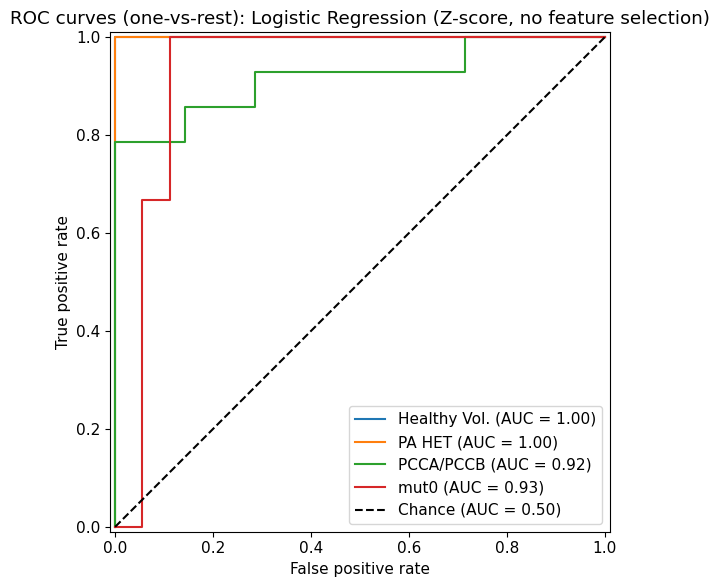

In [121]:
# 5) ROC curves (one-vs-rest): Logistic Regression (Z-score, no feature selection)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

classes_roc_lr = lr_fit.classes_
y_test_bin_lr = label_binarize(clf_z.y_test_, classes=classes_roc_lr)
n_classes_lr = len(classes_roc_lr)
y_score_lr = lr_fit.predict_proba(clf_z.X_test_s_)

fig, ax = plt.subplots(figsize=(7, 6))
for i in range(n_classes_lr):
    fpr, tpr, _ = roc_curve(y_test_bin_lr[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=classes_roc_lr[i]).plot(ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (one-vs-rest): Logistic Regression (Z-score, no feature selection)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

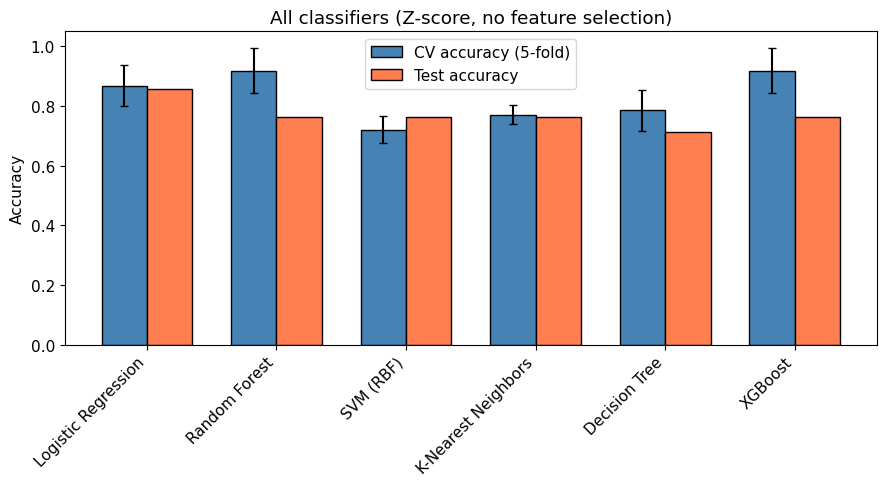

In [122]:
# 6) All models comparison (Z-score pipeline, no feature selection): CV and test accuracy
res_df_lr = pd.DataFrame(results_z)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(res_df_lr))
width = 0.35
ax.bar(x - width / 2, res_df_lr["CV Accuracy (mean)"], width, yerr=res_df_lr["CV std"], label="CV accuracy (5-fold)", capsize=3, color="steelblue", edgecolor="black")
ax.bar(x + width / 2, res_df_lr["Test Accuracy"], width, label="Test accuracy", color="coral", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(res_df_lr["Model"], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_title("All classifiers (Z-score, no feature selection)")
plt.tight_layout()
plt.show()

## K-means clustering and optimal k

Use elbow method and silhouette score to choose k; then cluster and compare with true labels.

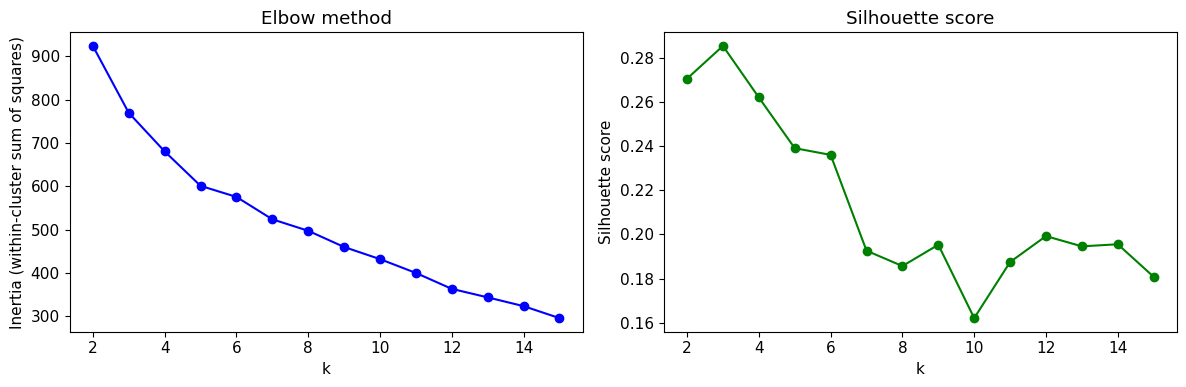

Optimal k by silhouette: 3
Silhouette scores: {2: 0.271, 3: 0.286, 4: 0.262, 5: 0.239, 6: 0.236, 7: 0.193, 8: 0.186, 9: 0.195, 10: 0.162, 11: 0.188, 12: 0.199, 13: 0.195, 14: 0.196, 15: 0.181}


In [123]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use scaled data (same as for classification)
X_clust = X_train_s  # or use X_filled scaled for full dataset
k_range = range(2, 16)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, km.labels_))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, "bo-")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia (within-cluster sum of squares)")
ax1.set_title("Elbow method")
ax2.plot(k_range, silhouettes, "go-")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette score")
plt.tight_layout()
plt.show()
best_k_sil = k_range[np.argmax(silhouettes)]
print("Optimal k by silhouette:", best_k_sil)
print("Silhouette scores:", dict(zip(k_range, [round(s, 3) for s in silhouettes])))

In [124]:
k_opt = best_k_sil
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clust)
train_conditions = y_train.values
cross_tab = pd.crosstab(train_conditions, cluster_labels, margins=True)
print("Cross-tabulation: True Condition vs K-means cluster")
display(cross_tab)

print("\nFinal silhouette score (k=%d):" % k_opt, round(silhouette_score(X_clust, cluster_labels), 3))

Cross-tabulation: True Condition vs K-means cluster


col_0,0,1,2,All
row_0,,,,
Healthy Vol.,5,0,0,5
PA HET,0,7,0,7
PCCA/PCCB,17,20,2,39
mut0,9,1,0,10
All,31,28,2,61



Final silhouette score (k=3): 0.286


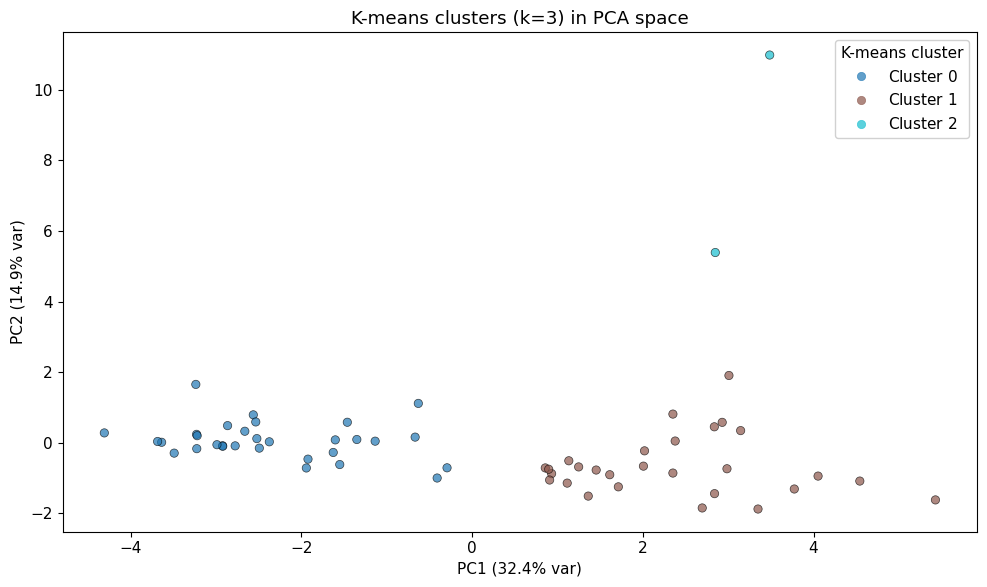

In [125]:
# PCA for 2D visualization of clusters (optional)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7, edgecolors="black", linewidths=0.5)
# Discrete legend: "Cluster 0", "Cluster 1", ... instead of colorbar
handles, labels = scatter.legend_elements(prop="colors")
ax.legend(handles, ["Cluster %s" % l for l in labels], title="K-means cluster", loc="best", framealpha=0.9)
ax.set_xlabel("PC1 ({:.1f}% var)".format(100 * pca.explained_variance_ratio_[0]))
ax.set_ylabel("PC2 ({:.1f}% var)".format(100 * pca.explained_variance_ratio_[1]))
ax.set_title("K-means clusters (k=%d) in PCA space" % k_opt)
plt.tight_layout()
plt.show()

### UMAP visualization

UMAP (Uniform Manifold Approximation and Projection) for 2D embedding of the same data, colored by K-means cluster and by true Condition.

/Users/francescavenditti/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


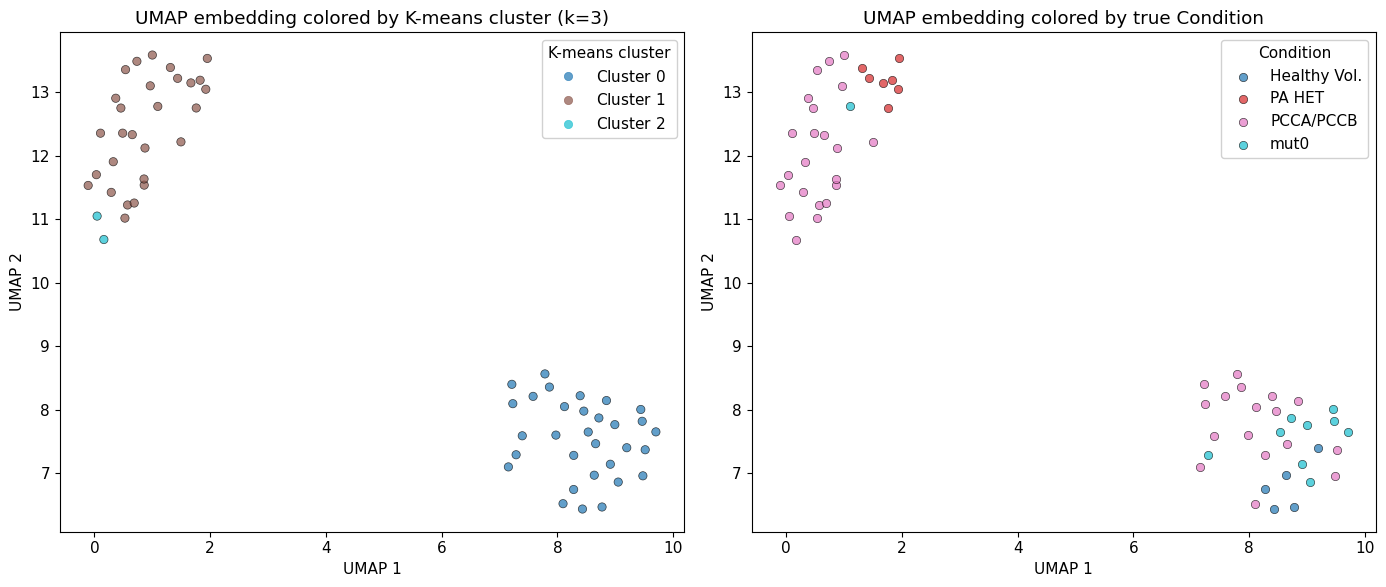

In [126]:
# UMAP 2D embedding (same data as PCA/K-means: X_clust, scaled training set)
try:
    import umap
    # Ensure numpy array for compatibility across umap-learn / scikit-learn versions
    X_umap_input = np.asarray(X_clust, dtype=np.float64)
    if np.any(~np.isfinite(X_umap_input)):
        X_umap_input = np.nan_to_num(X_umap_input, nan=0.0, posinf=0.0, neginf=0.0)
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_umap_input)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: colored by K-means cluster
    ax = axes[0]
    scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7, edgecolors="black", linewidths=0.5)
    handles, labels_leg = scatter.legend_elements(prop="colors")
    ax.legend(handles, ["Cluster %s" % str(l) for l in labels_leg], title="K-means cluster", loc="best", framealpha=0.9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title("UMAP embedding colored by K-means cluster (k=%d)" % k_opt)

    # Right: colored by true Condition
    ax = axes[1]
    conditions = y_train.values
    uniq = sorted(pd.Series(conditions).unique())
    colors_cond = plt.cm.tab10(np.linspace(0, 1, len(uniq)))
    for i, cond in enumerate(uniq):
        mask = conditions == cond
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], c=[colors_cond[i]], label=cond, alpha=0.7, edgecolors="black", linewidths=0.5)
    ax.legend(title="Condition", loc="best", framealpha=0.9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title("UMAP embedding colored by true Condition")

    plt.tight_layout()
    plt.show()
except ImportError:
    print("UMAP not installed. Run: pip install umap-learn")
except TypeError as e:
    if "ensure_all_finite" in str(e) or "check_array" in str(e):
        print("Version conflict: your scikit-learn and umap-learn are incompatible.")
        print("Fix: pip install -U umap-learn")
        print("(Original error: %s)" % e)
    else:
        raise